# Task 4.2 — Predict HAI Magnitude for H3N2 A/Massachusetts/18/2022 (D28)

**4.2 predict magnitude of antibody response - H3N2 A/Massachusetts/18/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Single strain titer / Metric: Spearman correlation
* Full description: HAI titer for H3N2 A/Massachusetts/18/2022 at Day 28

---

## Design notes

**Proxy target:** The target strain (H3N2 A/Massachusetts/18/2022) is absent from the training data.
We approximate it by averaging the Day 28 HAI titers of all other H3N2 strains present in the dataset.
All HAI columns are then dropped to prevent leakage.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale.
Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
AUTOML_MAX_MODELS = None
AUTOML_SEED = 1
AUTO_ML_MAX_RUNTIME_SECONDS = 60 * 1

STRAIN = 'H3N2 A/Massachusetts/18/2022'
TARGET_COL = 'H3N2_proxy_d28'  # proxy: target strain absent from training data
ONLY_TRANSCRIPTOMICS_PARTICIPANTS = True  # required: challenge participants all have TRAN data
FORCE_KEEP_TRANSCRIPTOMICS = True
MISSING_THRESHOLD = 0.5  # drop features missing in >50% of rows

In [2]:
CSV_PATH = '../../cleaned_data/train_combined.csv'
CHALLENGE_DATA_PATH = '../../cleaned_data'
SUBMISSION_PATH = '../submission'

In [3]:
import io
import os
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [4]:
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_tran = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_transcriptomics_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
challenge_data = challenge_data.merge(challenge_tran, on='participant_id', how='left')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 311)


### Preprocessing

`H3N2 A/Massachusetts/18/2022` is absent from the training set. We create a proxy target by row-wise averaging all available H3N2 D28 HAI titers, then filter to rows with a valid proxy. The pipeline then: drops all-null columns, coerces HAI strings, drops constant and sparse features, adds H3N2 aggregate features, and removes other-task `_d28`/`_d365` leakage columns. The same coercions are applied to challenge data in the same cells.

In [5]:
df = pd.read_csv(CSV_PATH)
print(f'Raw shape: {df.shape}')

Raw shape: (3757, 489)


In [6]:
h3n2_d28_cols = [c for c in df.columns if c.startswith('HAI_') and 'H3N2' in c and c.endswith('_d28')]
df[TARGET_COL] = df[h3n2_d28_cols].mean(axis=1)
print(f'Proxy target averaged from {len(h3n2_d28_cols)} H3N2 d28 strains')

df = df[df[TARGET_COL].notna()].reset_index(drop=True)
print(f'Rows with valid proxy target: {len(df)}')

Proxy target averaged from 25 H3N2 d28 strains
Rows with valid proxy target: 3646


/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_30895/692792383.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[TARGET_COL] = df[h3n2_d28_cols].mean(axis=1)


In [7]:
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns → {df.shape[1]} remaining')

Dropped 0 all-null columns → 490 remaining


### Coerce HAI string columns to numeric

Some `HAI_*` columns are stored as strings (e.g. `<10`). H2O treats those as categorical, which crashes `predict()`. Coerce all `HAI_*` string columns to numeric in both training and challenge data.

In [8]:
# str_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
# print(f'String columns ({len(str_cols)}): {str_cols}')

# hai_str_cols = [c for c in str_cols if c.startswith('HAI_')]
# for c in hai_str_cols:
#     df[c] = pd.to_numeric(df[c], errors='coerce')

# challenge_hai_str_cols = [c for c in challenge_data.select_dtypes(include=['object', 'str']).columns
#                           if c.startswith('HAI_')]
# for c in challenge_hai_str_cols:
#     challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')

# print(f'Coerced {len(hai_str_cols)} HAI string columns in training data.')
# print(f'Coerced {len(challenge_hai_str_cols)} HAI string columns in challenge data.')

### Drop constant features

Any column with only one unique value carries no signal. Filtering to participants with a valid proxy target may collapse some features.

In [9]:
constant_cols = [c for c in df.columns
                 if c != TARGET_COL and df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=constant_cols)
print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
print(f'Shape: {df.shape}')

Dropped 0 constant columns: []
Shape: (3646, 490)


### Transcriptomics stats

In [10]:
tran_cols = [c for c in df.columns if c.startswith('TRAN_')]
df_tran = df[df[tran_cols].notna().any(axis=1)].reset_index(drop=True)
print(f'Participants with TRAN data: {df_tran.shape[0]} / {df.shape[0]} '
      f'({df_tran.shape[0] / df.shape[0]:.1%})')

if ONLY_TRANSCRIPTOMICS_PARTICIPANTS:
    df = df_tran
    print(f'Filtered to TRAN-only participants. Shape: {df.shape}')

Participants with TRAN data: 394 / 3646 (10.8%)
Filtered to TRAN-only participants. Shape: (394, 490)


### Drop sparse features

Drop columns missing in more than `MISSING_THRESHOLD` of rows. `FORCE_KEEP_TRANSCRIPTOMICS = True` preserves all TRAN PCs since all challenge participants have TRAN data.

In [11]:
miss_frac = df.isna().mean()
sparse_cols = miss_frac[miss_frac > MISSING_THRESHOLD].index

if FORCE_KEEP_TRANSCRIPTOMICS:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL and c not in tran_cols]
else:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL]

df = df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns with >{MISSING_THRESHOLD:.0%} missing.')
print(f'Shape: {df.shape}')

surviving_tran = [c for c in df.columns if c.startswith('TRAN_')]
print(f'TRAN columns surviving sparse filter: {len(surviving_tran)} / {len(tran_cols)}')

Dropped 141 columns with >50% missing.
Shape: (394, 349)
TRAN columns surviving sparse filter: 290 / 290


### Drop other-task target columns

Challenge participants only have baseline data (d0 + d7). The `_d28` / `_d365` columns are targets for other tasks but are unavailable at inference time — drop them to prevent leakage.

In [12]:
other_target_cols = [c for c in df.columns
                     if (c.endswith('_d28') and c != TARGET_COL) or c.endswith('_d365')]
df = df.drop(columns=other_target_cols)
print(f'Dropped {len(other_target_cols)} other-task target columns.')
print(f'Shape: {df.shape}')

Dropped 33 other-task target columns.
Shape: (394, 316)


### Add H3N2 aggregate features

Row-wise H3N2 and H1N1 d0 averages provide a compact proxy-signal column. Applied to both training and challenge data.

In [13]:
h3n2_d0 = [c for c in df.columns if 'H3N2' in c and c.endswith('_d0')]
h1n1_d0 = [c for c in df.columns if 'H1N1' in c and c.endswith('_d0')]
all_d0 = [c for c in df.columns if c.startswith('HAI_') and c.endswith('_d0')]

df['HAI_mean_H3N2_d0'] = df[h3n2_d0].mean(axis=1)
df['HAI_mean_H1N1_d0'] = df[h1n1_d0].mean(axis=1)
df['HAI_mean_all_d0'] = df[all_d0].mean(axis=1)
df['HAI_n_measured_d0'] = df[all_d0].notna().sum(axis=1)
print(f'Added 4 HAI aggregate features. Shape: {df.shape}')

ch_h3n2_d0 = [c for c in challenge_data.columns if 'H3N2' in c and c.endswith('_d0')]
ch_h1n1_d0 = [c for c in challenge_data.columns if 'H1N1' in c and c.endswith('_d0')]
ch_all_d0 = [c for c in challenge_data.columns if c.startswith('HAI_') and c.endswith('_d0')]

challenge_data['HAI_mean_H3N2_d0'] = challenge_data[ch_h3n2_d0].mean(axis=1)
challenge_data['HAI_mean_H1N1_d0'] = challenge_data[ch_h1n1_d0].mean(axis=1)
challenge_data['HAI_mean_all_d0'] = challenge_data[ch_all_d0].mean(axis=1)
challenge_data['HAI_n_measured_d0'] = challenge_data[ch_all_d0].notna().sum(axis=1)
print(f'Challenge shape after aggregates: {challenge_data.shape}')

Added 4 HAI aggregate features. Shape: (394, 320)
Challenge shape after aggregates: (40, 315)


/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_30895/2849536846.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['HAI_mean_H3N2_d0'] = df[h3n2_d0].mean(axis=1)
/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_30895/2849536846.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['HAI_mean_H1N1_d0'] = df[h1n1_d0].mean(axis=1)
/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_30895/2849536846.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fram

In [14]:
hai_feature_cols = [c for c in df.columns if c.startswith('HAI_') and c != TARGET_COL]
for c in hai_feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    if c in challenge_data.columns:
        challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Forced float64 on {len(hai_feature_cols)} HAI feature columns in training and challenge data.')

print(f'\nFinal shape: {df.shape}')
print(f'Target ({TARGET_COL}) stats (log2):\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')

Forced float64 on 25 HAI feature columns in training and challenge data.

Final shape: (394, 320)
Target (H3N2_proxy_d28) stats (log2):
count    394.000000
mean       6.261026
std        2.294953
min        2.571928
25%        4.607642
50%        5.821928
75%        7.446928
max       14.321928
Name: H3N2_proxy_d28, dtype: float64

dtype counts:
float64    316
str          3
int64        1
Name: count, dtype: int64


---
## AutoML Setup

In [15]:
warnings.filterwarnings('ignore', category=UserWarning, module='h2o')
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "26.0.1" 2026-04-21; OpenJDK Runtime Environment Homebrew (build 26.0.1); OpenJDK 64-Bit Server VM Homebrew (build 26.0.1, mixed mode, sharing)
  Starting server from /Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpyisk66k7
  JVM stdout: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpyisk66k7/h2o_chayan_started_from_python.out
  JVM stderr: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpyisk66k7/h2o_chayan_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months and 19 days
H2O_cluster_name:,H2O_from_python_chayan_9eax73
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.98 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


In [16]:
hai_col_types = {c: 'real' for c in hai_feature_cols}
tran_col_types = {c: 'real' for c in surviving_tran}
col_types = {**hai_col_types, **tran_col_types}
data = h2o.H2OFrame(df, column_types=col_types)
print(f'H2OFrame shape: {data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (394, 320)


---
## AutoML Training

In [17]:
y = TARGET_COL
x = [c for c in data.columns if c not in (y, 'participant_id')]
print(f'Training samples: {data.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(
    max_models=AUTOML_MAX_MODELS,
    seed=AUTOML_SEED,
    nfolds=5,
    keep_cross_validation_predictions=True,
    max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS,
    exclude_algos=['DeepLearning', 'GLM'],
)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=data)
print('Training complete.')

Training samples: 394  |  Features: 318
Training complete.


In [18]:
lb_df = aml.leaderboard.as_data_frame()
lb_df

/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,StackedEnsemble_BestOfFamily_6_AutoML_1_202605...,1.105598,1.222346,0.853311,0.163169,1.222346
1,StackedEnsemble_BestOfFamily_5_AutoML_1_202605...,1.113903,1.240779,0.864313,0.163282,1.240779
2,StackedEnsemble_BestOfFamily_3_AutoML_1_202605...,1.114978,1.243175,0.862774,0.163287,1.243175
3,StackedEnsemble_AllModels_3_AutoML_1_20260531_...,1.118344,1.250694,0.864636,0.164600,1.250694
4,StackedEnsemble_AllModels_2_AutoML_1_20260531_...,1.120713,1.255998,0.867618,0.164858,1.255998
5,StackedEnsemble_BestOfFamily_2_AutoML_1_202605...,1.120941,1.256508,0.870733,0.165198,1.256508
6,GBM_grid_1_AutoML_1_20260531_185928_model_37,1.122547,1.260111,0.867821,0.166967,1.260111
7,GBM_grid_1_AutoML_1_20260531_185928_model_41,1.122915,1.260937,0.890611,0.167426,1.260937
8,XRT_1_AutoML_1_20260531_185928,1.123919,1.263193,0.869597,0.165988,1.263193
9,StackedEnsemble_AllModels_5_AutoML_1_20260531_...,1.124291,1.264031,0.872356,0.165800,1.264031


In [19]:
top_model = h2o.get_model(lb_df['model_id'].iloc[0])

top_base_model_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
top_base_model = h2o.get_model(top_base_model_id)

cv_preds = top_base_model.cross_validation_holdout_predictions().as_data_frame()['predict']
actuals = data[y].as_data_frame()[y]

rho, pval = spearmanr(actuals, cv_preds)
print(f'Prediction model:  {top_model.model_id}')
print(f'Scoring model:     {top_base_model.model_id}')
print(f'Task 4.2 — Spearman (best base model 5-fold CV): {rho:.3f}  (p={pval:.4f})')

Prediction model:  StackedEnsemble_BestOfFamily_6_AutoML_1_20260531_185928
Scoring model:     GBM_grid_1_AutoML_1_20260531_185928_model_37
Task 4.2 — Spearman (best base model 5-fold CV): 0.812  (p=0.0000)


/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


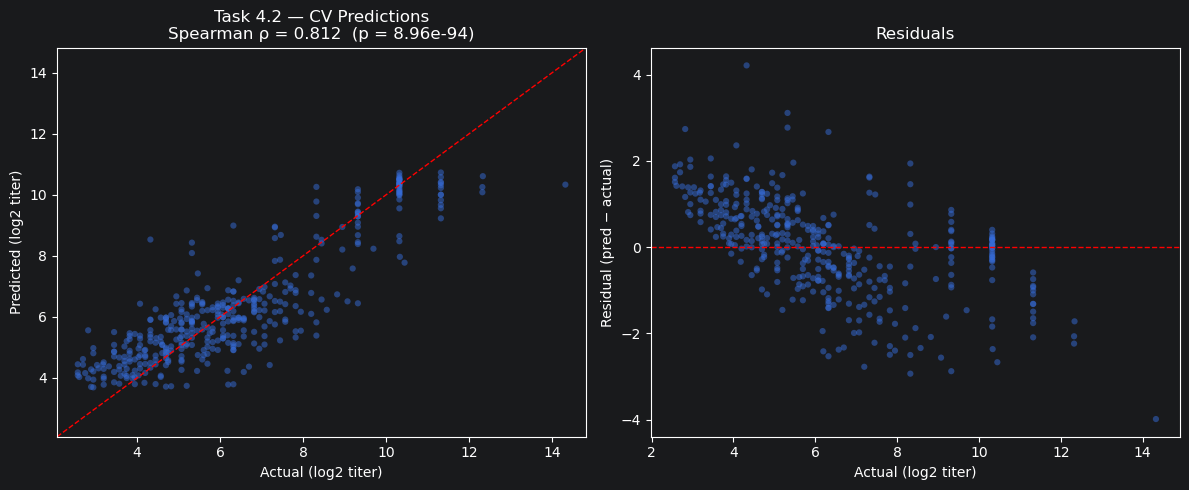

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(actuals, cv_preds, alpha=0.5, s=20, edgecolors='none')
lim = [min(actuals.min(), cv_preds.min()) - 0.5,
       max(actuals.max(), cv_preds.max()) + 0.5]
ax.plot(lim, lim, 'r--', linewidth=1)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Actual (log2 titer)')
ax.set_ylabel('Predicted (log2 titer)')
ax.set_title(f'Task 4.2 — CV Predictions\nSpearman ρ = {rho:.3f}  (p = {pval:.2e})')

ax = axes[1]
residuals = cv_preds.values - actuals.values
ax.scatter(actuals, residuals, alpha=0.5, s=20, edgecolors='none')
ax.axhline(0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Actual (log2 titer)')
ax.set_ylabel('Residual (pred − actual)')
ax.set_title('Residuals')

plt.tight_layout()
plt.show()

Best base model: GBM_grid_1_AutoML_1_20260531_185928_model_37


,variable,relative_importance,scaled_importance,percentage
0,HAI_H3N2 A/Hong Kong/2671/2019_d0,1464.051270,1.000000,0.146191
1,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,1309.677612,0.894557,0.130776
2,HAI_mean_H3N2_d0,1216.330933,0.830798,0.121455
3,HAI_H3N2 A/South Australia/34/2019_d0,937.058350,0.640045,0.093569
4,HAI_H1N1 A/Brisbane/2/2018_d0,776.436890,0.530334,0.077530
5,PART_arm_name,611.901978,0.417951,0.061101
6,HAI_H3N2 A/Hong Kong/4801/2014_d0,205.143677,0.140121,0.020484
7,HAI_Vic B/Colorado/6/2017_d0,177.648392,0.121340,0.017739
8,HAI_mean_all_d0,159.912125,0.109226,0.015968
9,HAI_H3N2 A/Switzerland/9715293/2013_d0,158.747620,0.108430,0.015852


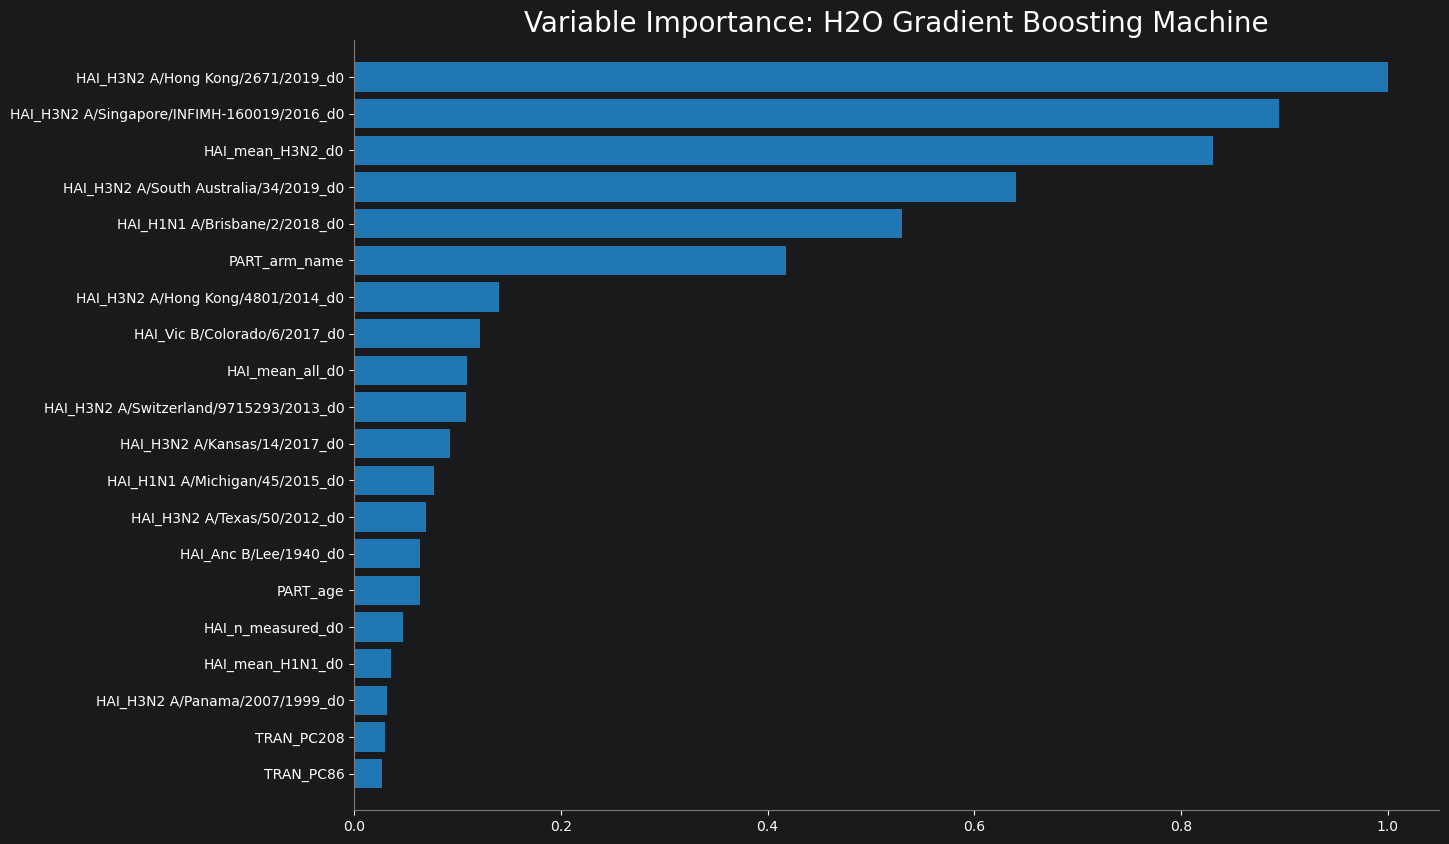

<Figure size 640x480 with 0 Axes>

In [21]:
print(f'Best base model: {top_base_model.model_id}')
varimp = top_base_model.varimp(use_pandas=True)
display(varimp.head(20))
top_base_model.varimp_plot(num_of_features=20)

In [22]:
challenge_col_types = {c: 'real' for c in hai_feature_cols if c in challenge_data.columns}
challenge_col_types.update({c: 'real' for c in surviving_tran if c in challenge_data.columns})
challenge_hf = h2o.H2OFrame(challenge_data, column_types=challenge_col_types)
y_pred = top_model.predict(challenge_hf).as_data_frame()['predict']

os.makedirs(SUBMISSION_PATH, exist_ok=True)
results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.2': np.exp2(y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_2.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,Participant_ID,Task_4.2
0,2024_UGA.ID_077,22.660063
1,2024_UGA.ID_086,19.083767
2,2024_UGA.ID_128,195.609476
3,2024_UGA.ID_170,30.886807
4,2024_UGA.ID_179,27.122383
5,2024_UGA.ID_215,72.560128
6,2024_UGA.ID_219,20.725525
7,2024_UGA.ID_275,17.047313
8,2024_UGA.ID_295,18.156018
9,2024_UGA.ID_296,11.703030


In [23]:
model_path = h2o.save_model(model=top_model, path='..', filename='../models/model_4.2', force=True)
print(f'Model saved to: {model_path}')

Model saved to: /Users/chayan/repos/ucsd/cmi-flu-prediction-challenge-capstone/automl_models/models/model_4.2


In [24]:
h2o.cluster().shutdown()

H2O session _sid_b5ca closed.


---
## Conclusion

- **Leader model:** StackedEnsemble or best GBM (used for challenge predictions and saved)
- **Scoring model:** best non-StackedEnsemble base model (used for CV Spearman and varimp)
- **CV Spearman:** see cell above
- **Training samples:** ~394 (participants with TRAN data and a valid H3N2 proxy target)
- **Model saved:** `automl_models/models/model_4.2`

**Target:** Proxy for HAI titer of H3N2 A/Massachusetts/18/2022 at D28. The challenge strain is absent from training data; the proxy is the row-wise mean of all available H3N2 D28 HAI titers.

**Feature set:** Demographics + d0 HAI titers (including H3N2/H1N1 aggregate features) + 290 TRAN PCs, after dropping `_d28`/`_d365` leakage columns and sparse features. `FORCE_KEEP_TRANSCRIPTOMICS = True` preserves all TRAN PCs. `ONLY_TRANSCRIPTOMICS_PARTICIPANTS = True` restricts training to participants with Day 7 transcriptomics. All HAI and TRAN columns are explicitly typed `real` on both training and challenge H2OFrames.

**Imputation note:** No manual imputation. H2O's tree models handle `NaN` natively at each split.

To reload the model: `h2o.load_model('automl_models/models/model_4.2')`